# Lab 13 — Vision Transformers: ViT e DeiT-Tiny

## Objetivos
1. Explorar ViT pré-treinado com `timm` (inferência zero-shot no ImageNet)
2. Fine-tuning do DeiT-Tiny no CIFAR-10 com HuggingFace Transformers
3. Comparar com CNN do zero (Lab 10) e Transfer Learning CNN (Lab 12)
4. Salvar artefato para deploy via FastAPI

---
**GPU recomendada** — DeiT-Tiny é leve (~5.7M params) e roda em CPU, mas GPU acelera o treino ~5×.

In [1]:
# %pip install transformers timm accelerate datasets torch torchvision pillow matplotlib

## Parte 1 — ViT pré-treinado com timm (ImageNet)

**O que é a biblioteca `timm`?**

O `timm` (*PyTorch Image Models*) é uma biblioteca open-source criada por Ross Wightman. Ela se tornou o padrão ouro na comunidade de Deep Learning para Visão Computacional porque reúne a maior coleção de arquiteturas de ponta (State-of-the-Art) implementadas em PyTorch.

* **Por que não usar o `torchvision`?** O `torchvision` é ótimo, mas costuma focar em modelos mais clássicos e consolidados. O `timm`, por outro lado, é atualizado constantemente com os modelos mais novos recém-publicados em artigos científicos (como diversas variantes de Vision Transformers, ConvNeXts, etc).
* **Vantagens:** Com um simples comando (`timm.create_model`), você consegue instanciar centenas de modelos diferentes já com os pesos pré-treinados, além de poder extrair facilmente as transformações (pré-processamento) exatas que as imagens precisam ter para aquele modelo específico.

🔗 **Links úteis para consulta e aprofundamento:**
* [Documentação Oficial do timm (via Hugging Face)](https://huggingface.co/docs/timm/index)
* [Repositório no GitHub (para consultar modelos e novidades)](https://github.com/huggingface/pytorch-image-models)

In [1]:
import timm
import torch
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando: {device}')

# Listar modelos ViT disponíveis no timm
vit_models = timm.list_models('deit_*', pretrained=True)


print(f'Modelos ViT disponíveis: {len(vit_models)}')
print('Exemplos:', vit_models[:5])

Usando: cuda
Modelos ViT disponíveis: 8
Exemplos: ['deit_base_distilled_patch16_224.fb_in1k', 'deit_base_distilled_patch16_384.fb_in1k', 'deit_base_patch16_224.fb_in1k', 'deit_base_patch16_384.fb_in1k', 'deit_small_distilled_patch16_224.fb_in1k']


In [2]:
# Carregar DeiT-Tiny pré-treinado via timm
model_timm = timm.create_model('deit_tiny_patch16_224', pretrained=True)
model_timm.eval().to(device)

print(f'Parâmetros: {sum(p.numel() for p in model_timm.parameters()):,}')

# Pré-processamento padrão do timm
data_config = timm.data.resolve_model_data_config(model_timm)
transforms = timm.data.create_transform(**data_config, is_training=False)
print('\nTransforms:', transforms)

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Parâmetros: 5,717,416

Transforms: Compose(
    Resize(size=248, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)


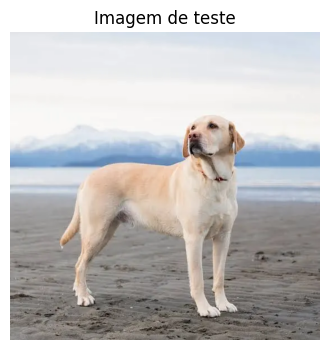

Top-5 previsões (DeiT-Tiny, ImageNet):
  Labrador retriever              60.2%
  Saluki                          12.5%
  Great Dane                      4.0%
  golden retriever                2.0%
  English foxhound                1.0%


In [6]:
import urllib.request
from PIL import Image
import torch
import matplotlib.pyplot as plt

# 1. Baixar uma imagem de teste automaticamente para garantir que o código funcione
url_imagem = 'https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQs1OtM7dKWRBrkYKSSnldgGFOYJicEf-PpieXLBgTepd2TYEGWFViCaGKBv4Ei1BbvNiq7Fcr61tCbd26Exzgl0O0rsq2J6wE9KMSuNBU&s=10'
urllib.request.urlretrieve(url_imagem, 'imagem_teste.jpg')

# 2. Carregar a imagem
img = Image.open('imagem_teste.jpg').convert('RGB')

# 3. Pré-processamento
# Aplicamos os 'transforms' e usamos .unsqueeze(0) para adicionar a dimensão do lote (batch).
# Modelos no PyTorch esperam o formato [batch_size, canais, altura, largura].
# Como temos só uma imagem, o formato fica [1, 3, 224, 224].
tensor = transforms(img).unsqueeze(0).to(device)

# 4. Inferência (Passagem no modelo)
# O torch.no_grad() desliga o cálculo de gradientes. Como não estamos treinando,
# isso economiza muita memória e deixa a inferência mais rápida.
with torch.no_grad():
    logits = model_timm(tensor)  # Saída bruta do modelo (valores matemáticos sem limite)
    probs = torch.softmax(logits, dim=1)[0]  # Softmax transforma a saída em probabilidades (0 a 1)

# 5. Pegar as 5 maiores probabilidades e seus respectivos índices
top5_probs, top5_idx = torch.topk(probs, 5)

# 6. Carregar os rótulos originais do ImageNet (1000 classes) para saber os nomes
urllib.request.urlretrieve(
    'https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt',
    'imagenet_classes.txt'
)
with open('imagenet_classes.txt') as f:
    imagenet_classes = [l.strip() for l in f]

# 7. Visualização
plt.figure(figsize=(4, 4))
plt.imshow(img); plt.axis('off'); plt.title('Imagem de teste')
plt.show()

print('Top-5 previsões (DeiT-Tiny, ImageNet):')
for i, p in zip(top5_idx, top5_probs):
    print(f'  {imagenet_classes[i]:30s}  {p*100:.1f}%')

## Parte 2 — Fine-tuning do DeiT-Tiny no CIFAR-10

In [7]:
import json
from pathlib import Path
import torchvision
import torchvision.transforms as T
from transformers import AutoImageProcessor, AutoModelForImageClassification

CLASSES = ['aviao', 'automovel', 'passaro', 'gato', 'cervo',
           'cachorro', 'sapo', 'cavalo', 'navio', 'caminhao']
MODEL_ID = 'facebook/deit-tiny-patch16-224'

In [8]:
# Processor do HuggingFace cuida de resize + normalização
processor = AutoImageProcessor.from_pretrained(MODEL_ID)

def transform_hf(examples):
    """Compatível com HuggingFace datasets (pode adaptar para torchvision)."""
    return processor(images=examples, return_tensors='pt')

# Dataset CIFAR-10 via torchvision com transforms manuais
size = processor.size.get('height', 224)

tf_train = T.Compose([
    T.Resize((size, size)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std),
])
tf_val = T.Compose([
    T.Resize((size, size)),
    T.ToTensor(),
    T.Normalize(mean=processor.image_mean, std=processor.image_std),
])

trainset = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=tf_train)
testset  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=tf_val)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2)

print(f'Treino: {len(trainset)} | Teste: {len(testset)}')

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.6k [00:00<?, ?B/s]

KeyboardInterrupt: 

In [9]:
# Carrega DeiT-Tiny e substitui o head para 10 classes
model_deit = AutoModelForImageClassification.from_pretrained(
    MODEL_ID,
    num_labels=10,
    ignore_mismatched_sizes=True,   # descarta o classifier original (1000 classes)
)
model_deit = model_deit.to(device)

treinaveis = sum(p.numel() for p in model_deit.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_deit.parameters())
print(f'Parâmetros treináveis: {treinaveis:,} / {total:,}')

[transformers] You passed `num_labels=10` which is incompatible to the `id2label` map of length `1000`.


pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 23.0MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

[transformers] ViTForImageClassification LOAD REPORT from: facebook/deit-tiny-patch16-224
Key               | Status   |                                                                                           
------------------+----------+-------------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 192]) vs model:torch.Size([10, 192])

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


Parâmetros treináveis: 5,526,346 / 5,526,346


In [10]:
import torch.nn as nn

optimizer = torch.optim.AdamW(model_deit.parameters(), lr=2e-5, weight_decay=0.01)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

historico = {'train_acc': [], 'val_acc': []}

for epoch in range(10):
    model_deit.train()
    corretos = total_b = 0
    for imgs, labels in trainloader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        # HuggingFace espera pixel_values
        outputs = model_deit(pixel_values=imgs)
        loss = criterion(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        corretos += (outputs.logits.argmax(1) == labels).sum().item()
        total_b += labels.size(0)

    train_acc = 100 * corretos / total_b

    model_deit.eval()
    c_val = t_val = 0
    with torch.no_grad():
        for imgs, labels in testloader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = model_deit(pixel_values=imgs)
            c_val += (out.logits.argmax(1) == labels).sum().item()
            t_val += labels.size(0)

    val_acc = 100 * c_val / t_val
    scheduler.step()

    historico['train_acc'].append(train_acc)
    historico['val_acc'].append(val_acc)
    print(f'Época {epoch+1:02d}/10 | Treino: {train_acc:.1f}% | Val: {val_acc:.1f}%')

model.safetensors: reconstructing file:   0%|          |  0.00B / 22.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Época 01/10 | Treino: 88.7% | Val: 93.9%
Época 02/10 | Treino: 95.8% | Val: 95.0%
Época 03/10 | Treino: 97.4% | Val: 95.4%
Época 04/10 | Treino: 98.4% | Val: 95.4%
Época 05/10 | Treino: 99.1% | Val: 95.8%
Época 06/10 | Treino: 99.5% | Val: 96.1%
Época 07/10 | Treino: 99.7% | Val: 96.2%
Época 08/10 | Treino: 99.9% | Val: 96.1%
Época 09/10 | Treino: 100.0% | Val: 96.3%
Época 10/10 | Treino: 100.0% | Val: 96.3%


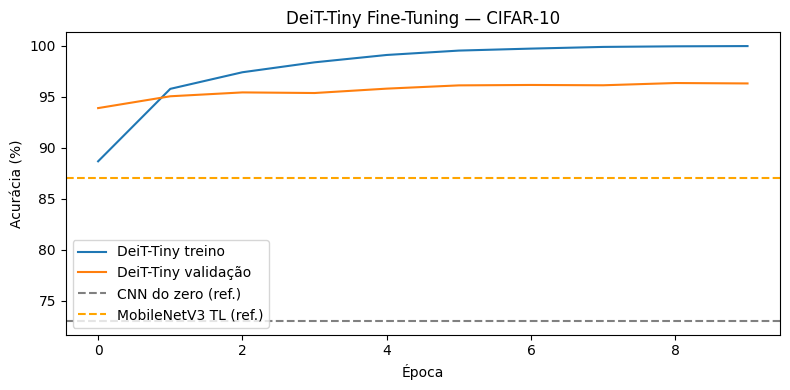

Melhor val acc: 96.3%


In [11]:
plt.figure(figsize=(8, 4))
plt.plot(historico['train_acc'], label='DeiT-Tiny treino')
plt.plot(historico['val_acc'],   label='DeiT-Tiny validação')
plt.title('DeiT-Tiny Fine-Tuning — CIFAR-10')
plt.xlabel('Época'); plt.ylabel('Acurácia (%)')
plt.legend(); plt.tight_layout(); plt.show()

print(f'Melhor val acc: {max(historico["val_acc"]):.1f}%')

## Parte 3 — Salvar artefato

In [12]:
artifacts_dir = Path('artifacts/deit_cifar10')
artifacts_dir.mkdir(parents=True, exist_ok=True)

# salva no formato HuggingFace (config + pesos)
model_deit.save_pretrained(str(artifacts_dir))
processor.save_pretrained(str(artifacts_dir))

metadata = {
    'model_name': 'DeiT-Tiny (fine-tuned CIFAR-10)',
    'base_model': MODEL_ID,
    'dataset': 'CIFAR-10',
    'num_classes': 10,
    'classes': CLASSES,
    'val_acc': round(max(historico['val_acc']), 2),
}
Path('artifacts/metadata.json').write_text(
    json.dumps(metadata, indent=2, ensure_ascii=False), encoding='utf-8'
)

print('Artefatos salvos:')
for f in sorted(Path('artifacts').rglob('*')):
    if f.is_file():
        print(f'  {f}  ({f.stat().st_size/1024:.0f} KB)')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Artefatos salvos:
  artifacts/deit_cifar10/config.json  (1 KB)
  artifacts/deit_cifar10/model.safetensors  (21609 KB)
  artifacts/deit_cifar10/preprocessor_config.json  (0 KB)
  artifacts/metadata.json  (0 KB)


### Como baixar os artefatos para a sua máquina?

No Google Colab, a forma mais fácil e segura de baixar uma pasta inteira é compactá-la (zip) primeiro. Podemos fazer isso usando a biblioteca `shutil` e, em seguida, disparar o download com `google.colab.files`.

In [ ]:
import shutil
from google.colab import files

print('Compactando a pasta de artefatos...')
# Cria um arquivo 'deit_artifacts.zip' contendo todo o conteúdo da pasta 'artifacts'
shutil.make_archive('deit_artifacts', 'zip', 'artifacts')

print('Iniciando o download...')
# Abre a janela de download no seu navegador
files.download('deit_artifacts.zip')

---
## Exercícios

1. **Comparativo completo:** monte uma tabela com acurácia final e tempo de treino para CNN (Lab10), MobileNetV3 (Lab12) e DeiT-Tiny (Lab13).

2. **Swin-Tiny:** substitua `deit-tiny` por `microsoft/swin-tiny-patch4-window7-224`. O que muda na arquitetura? Como os resultados se comparam?
